# Interactive Notebook 01 - Introduction to PWM:

This interactive Jupyter notebook is intended as an introduction to the basics of Pulse width modulation (and to the basics of Python programming and Jupyter notebooks). 

For help with the installation of the required software, consider the comments in ```CTPD_course\interactive_notebooks\README.md```.
Throughout the exercises, we will be using a combination of scientific computation libraries from the [JAX](https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html) ecosystem and visualize them with [matplotlib](https://matplotlib.org/) and [ipywidgets](https://ipywidgets.readthedocs.io/en/stable/).

### Preliminaries & Imports:

In [1]:
# automatically reloads imported ```.py```-files once they are changed and saved
%load_ext autoreload
%autoreload 2

In [2]:
%%html
<style>
div.jupyter-widgets.widget-label {display: none;}
</style>

In [3]:
# imports required packages
from functools import partial
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
mpl.rcParams.update({'font.size': 20})
import jax
import jax.numpy as jnp

(**Optional**: If you have LaTeX installed, you can use the following lines for pretty rendering of plot labels.
Any LaTeX installation should work, as long as all the required packages are installed, e.g., [MiKTeX](https://miktex.org/) or [TeXLive](https://www.tug.org/texlive/).

If you do not have LaTeX installed, you can comment the next cell out or skip it.

In [4]:
rc('font',**{'family':'serif','serif':['Helvetica']})
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble']=r"\usepackage{bm}\usepackage{amsmath}\usepackage{upgreek}"

---
## Signal generation example:

To get a first feeling for signal processing in Python, let us build the PWM carrier signal step-by-step and visualize it.

The following creates a discretized time array with $t \in [0, 10T_\mathrm{p})$ consisting of $10000$ elements. In this context, $f_{\mathrm{c}} = 10 \mathrm{Hz}$ is the carrier frequency and $T_\mathrm{p} = 1 / f_{\mathrm{c}}$ the pulse period.

In [5]:
carrier_freq = 10  # Hz
T_p = 1 / carrier_freq
t = jnp.linspace(0, 10*T_p, 10000)
print(t.shape)

(10000,)


This creates an array with $10000$ elements, that is a discretization of a sinusoidal signal with $f_{\mathrm{c}}$ and amplitude $1$:

In [6]:
x_t = jnp.sin(2 * jnp.pi * carrier_freq * t)
print(x_t.shape)

(10000,)


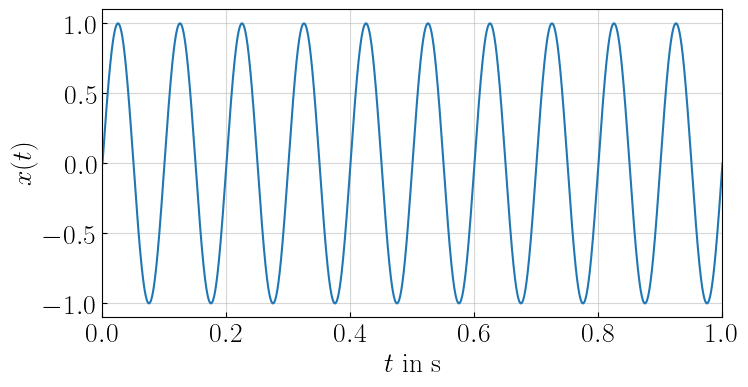

In [7]:
# Visualization:
fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.plot(t, x_t)

ax.grid(alpha=0.5)
ax.set_ylabel("$x(t)$")
ax.set_xlabel("$t$ in s")
ax.set_ylim(-1.1, 1.1)
ax.set_xlim(t[0], t[-1])
ax.tick_params(which="major", axis="y", direction="in")
ax.tick_params(which="both", axis="x", direction="in")

plt.show()

Now we are implementing a function for the generation of triangular signals.
The steps are:
- Normalization of time with the pulse period, i.e., $\tilde{t} = t / T_\mathrm{p}$
- Phase shift of normalized time with $\varphi / (2\pi)$
- Modulo operation due to periodicity with normalized period $\tilde{T} = 1.0$
- For the first half of each period, the signal is $1.0 - 4.0 \cdot \tilde{t}$
- for the second half, it is $4.0 \cdot \tilde{t} - 3.0$

In [8]:
def triangular_signal(t, frequency=1.0, amplitude=1.0, phase=0.0):

    T_p = 1.0 / frequency
    t_normalized = t / T_p
    t_normalized = t_normalized + phase / (2 * jnp.pi)
    t_normalized = t_normalized % 1.0

    triangle = jnp.where(
        t_normalized < 0.5,
        1.0 - 4.0 * t_normalized,
        4.0 * t_normalized - 3.0,
    )

    return amplitude * triangle

In [9]:
c_t = triangular_signal(t, frequency=carrier_freq, amplitude=1.0, phase=0.0)

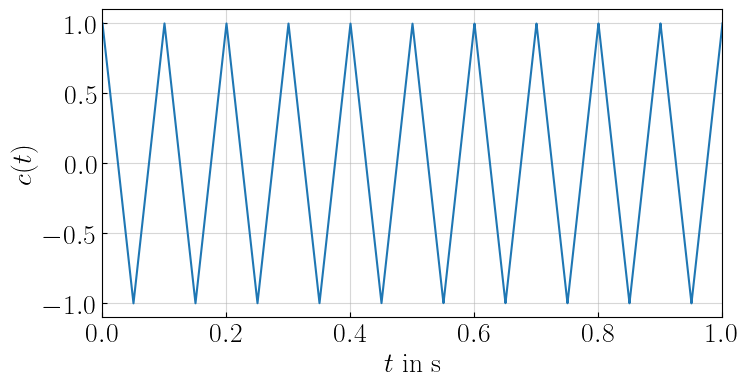

In [10]:
# Visualization:
fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.plot(t, c_t)

ax.grid(alpha=0.5)
ax.set_ylabel("$c(t)$")
ax.set_xlabel("$t$ in s")
ax.set_ylim(-1.1, 1.1)
ax.set_xlim(t[0], t[-1])
ax.tick_params(which="major", axis="y", direction="in")
ax.tick_params(which="both", axis="x", direction="in")

plt.show()

In the following, we will be using the triangluar carrier signal.

---
## Single-Phase PWM:
Based on the computed carrier signal, we will now implement a simple single-phase PWM.

In [11]:
u_dc = 40  # V, exemplary dc-link voltage, not really needed here
u_ref_freq = 1  # Hz, exemplary targeted signal frequency
m = 1.0  # exemplary modulation index

# computes the reference switching function and the corresponding reference voltage signal
s_ref_t = m * jnp.sin(u_ref_freq * 2 * jnp.pi * t)
u_ref_t = u_dc / 2 * s_ref_t

# compute resulting switching states:
s_t = jnp.where(s_ref_t > c_t, 1, -1)

Computes the normalized integral difference according to

$ e(t) = \frac{1}{T_\mathrm{p}} \int_{t_0}^t (s^*(\tau) - s(\tau)) \mathrm{d}\tau$,

which is approximated as

$ e(t) = \frac{1}{T_\mathrm{p}} \sum_{t_0}^t (s^*(\tau) - s(\tau)) \Delta t$,

where $\Delta t$ is the time difference between two sampling instances.

In [12]:
delta_t = t[1] - t[0]
e_t = 1/T_p * jnp.cumsum(s_ref_t - s_t) * delta_t

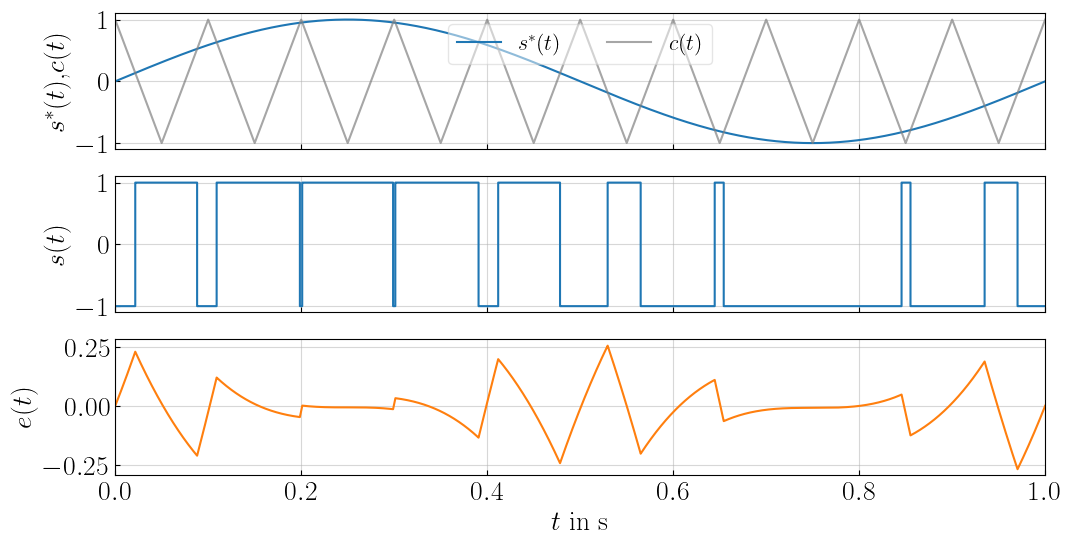

In [13]:
# Visualization:
fig, axs = plt.subplots(3,1, figsize=(12,6), sharex=True)

ax = axs[0]
ax.plot(t, s_ref_t, color="tab:blue", label="$s^*(t)$")
ax.plot(t, c_t, color="grey", alpha=0.7, label="$c(t)$")
ax.set_ylim(-1.1, 1.1)

ax.set_ylabel("$s^*(t)$,$c(t)$")
ax.legend(
    prop={"size": 16},
    framealpha=0.5,
    loc="upper center",
    fancybox=True,
    shadow=False,
    ncols=5,
)

ax = axs[1]
ax.step(t, s_t, color="tab:blue")
ax.set_ylabel("$s(t)$")
ax.set_ylim(-1.1, 1.1)


ax = axs[2]
ax.plot(t[:e_t.shape[0]], e_t, color="tab:orange")
ax.set_ylabel("$e(t)$")

for ax in axs:
    ax.grid(alpha=0.5)
    
    ax.set_xlim(t[0], t[-1])
    ax.tick_params(which="major", axis="y", direction="in")
    ax.tick_params(which="both", axis="x", direction="in")

axs[-1].set_xlabel("$t$ in s")

plt.show()

---
## Three-Phase Sinusoidal PWM:

For the three-phase PWM, we simply need two phase-shifted sinusoidal reference switching signals additionally to the first one:

$s^*_\mathrm{a}(t) = m^* \cdot \mathrm{sin}(\omega t)$

$s^*_\mathrm{b}(t) = m^* \cdot \mathrm{sin}(\omega t - \frac{2}{3} \pi)$

$s^*_\mathrm{c}(t) = m^* \cdot \mathrm{sin}(\omega t + \frac{2}{3} \pi)$

They are stacked into the variable ```s_ref_t``` to form a ```[10000, 3]``` matrix.

For the computation of the switching signals $s_\mathrm{a}(t)$, $s_\mathrm{b}(t)$, $s_\mathrm{c}(t)$, the carrier signal ```c_t``` is given an extra dimension using ```[..., None]```.
This changes its shape from ```[10000,]``` to ```[10000, 1]```. As a result, the function ```jnp.where``` can [broadcast](https://numpy.org/doc/stable/user/basics.broadcasting.html) the inputs.

In [14]:
def compute_three_phase_signals(m, u_ref_freq, t, c_t, u_dc):
    omega = u_ref_freq * 2 * jnp.pi
    s_ref_t = jnp.array(
        [
            m * jnp.sin(omega * t),
            m * jnp.sin(omega * t - jnp.pi * 2 / 3),
            m * jnp.sin(omega * t + jnp.pi * 2 / 3),
        ]
    ).T
    u_ref_t = u_dc / 2  * s_ref_t

    s_t = jnp.where(s_ref_t > c_t[..., None], 1, -1)

    return u_ref_t, s_ref_t, s_t

In [15]:
u_ref_t, s_ref_t, s_t = compute_three_phase_signals(m=0.7, u_ref_freq=2.5, t=t, c_t=c_t, u_dc=u_dc)
s_ref_t.shape

(10000, 3)

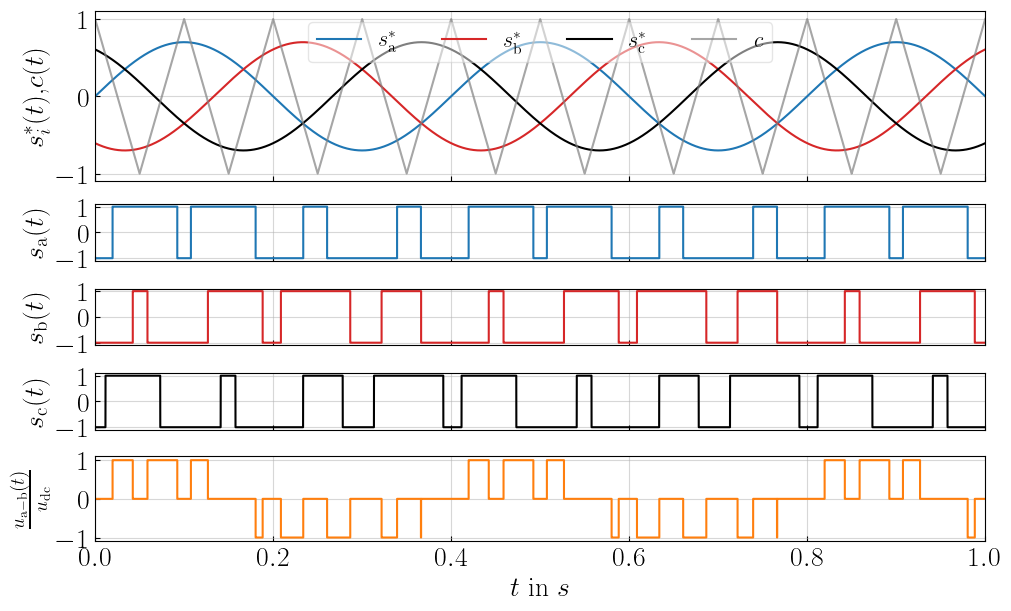

In [16]:
fig_left, axs = plt.subplots(
    5, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1, 1, 1.5]}, constrained_layout=True
)
axs[0].plot(t, s_ref_t[..., 0], color="tab:blue", label="$s^*_\\mathrm{a}$")
axs[0].plot(t, s_ref_t[..., 1], color="tab:red", label="$s^*_\\mathrm{b}$")
axs[0].plot(t, s_ref_t[..., 2], color="black", label="$s^*_\\mathrm{c}$")
axs[0].plot(t, c_t, color="grey", alpha=0.7, label="$c$")
axs[1].step(t, s_t[..., 0], color="tab:blue")
axs[2].step(t, s_t[..., 1], color="tab:red")
axs[3].step(t, s_t[..., 2], color="black")
axs[4].step(t, (s_t[..., 0] - s_t[..., 1]) / 2, color="tab:orange")


for ax in axs:
    ax.grid(alpha=0.5)
    ax.tick_params(which="major", axis="y", direction="in")
    ax.tick_params(which="both", axis="x", direction="in")
    ax.set_xlim(t[0], t[-1])

axs[0].legend(
    prop={"size": 16},
    framealpha=0.5,
    loc="upper center",
    fancybox=True,
    shadow=False,
    ncols=5,
)
axs[0].set_ylim(-1.1, 1.1)

axs[0].set_ylabel("$s^*_i(t)$,$c(t)$")
axs[1].set_ylabel("$s_\\mathrm{a}(t)$")
axs[2].set_ylabel("$s_\\mathrm{b}(t)$")
axs[3].set_ylabel("$s_\\mathrm{c}(t)$")
axs[4].set_ylabel("$\\frac{u_\\mathrm{a-b}(t)}{u_\\mathrm{dc}}$")
axs[-1].set_xlabel("$t$ in $s$")

plt.show()

### Interactive plot:

Before getting into the interactive plot itself, we define two further helper functions. They help us visualize the space vectors in $\alpha\beta$-coordinates.

The following is an implementation of the clarke transformation used to transform quantities from the $\mathrm{a}\mathrm{b}\mathrm{c}$-coordiante system to $\alpha\beta$-coordinates:

$\boldsymbol{x}_{\alpha\beta} = \begin{bmatrix} 2/3 & - 1/3 & -1/3 \\ 0 & 1 / \sqrt{3} & -1 / \sqrt{3} \end{bmatrix} \boldsymbol{x}_{\mathrm{a}\mathrm{b}\mathrm{c}}$

The function expects the input as a vector with shape ```[3,]``` and outputs a vector with shape ```[2,]```.

In [17]:
def simplified_clarke_transformation(x_abc):
    T_abc2albet = jnp.array(
        [
            [2 / 3, -1 / 3, -1 / 3],
            [0, 1 / jnp.sqrt(3), -1 / jnp.sqrt(3)],
        ]
    )
    return T_abc2albet @ x_abc

The following is used to generate the all possible active space vectors in $\alpha\beta$-coordinates.

Note the usage of the ```simplified_clarke_transformation``` even though the input array is of shape ```[8, 3]```.
The usual ```simplified_clarke_transformation``` would not be able to deal with this input, because attempting the matrix multiplication with shapes ```[2,3] @ [8, 3]``` would throw an error.
However, we can use the ```jax.vmap``` transformation (see [here](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html) for more documentation) to create a vectorized version of ```simplified_clarke_transformation``` that expects and extra dimension as the first dimension of the input and maps the function (Alternatively, you could also transpose the ```all_possible_states``` to have a matrix multiplication of ```[2,3] @ [3, 8]``` and then transpose the result to get a ```[8, 2]``` matrix. However, we wanted to introduce ```jax.vmap```, as it can be very convinient).

In [18]:
def compute_pwm_space_vectors():

    all_possible_states = jnp.array(
        [
            [-1, -1, -1],
            [-1, -1, 1],
            [-1, 1, -1],
            [-1, 1, 1],
            [1, -1, -1],
            [1, -1, 1],
            [1, 1, -1],
            [1, 1, 1],
        ]
    )
    return jax.vmap(simplified_clarke_transformation)(all_possible_states)

In [19]:
# activates interactive mode for matplotlib
%matplotlib widget

In [20]:
# imports the implementation of the interactive PWM visualizer, the Python file is located next to this notebook, if you want to take a look
from helper_functions import InteractivePWMVisualizer

In [21]:
# setup parameters and carrier signal

u_dc = 40  # V

carrier_freq = 50  # Hz
T = 1 / carrier_freq
t = jnp.linspace(0, 20*T, 1000)

c_t = triangular_signal(t, frequency=50.0, amplitude=1.0)

There are two unsolved issues for this visualization:
- If the full left half of the plot is not showing up, rerun the cell.
- If some part of the plot is not showing, slightly resizing the window for the left plot usually fixes the issue.

In [23]:
plt.close('all')
plt.ioff()

visualizer = InteractivePWMVisualizer(
    t,
    c_t,
    u_dc,
    compute_three_phase_signals=jax.jit(compute_three_phase_signals),
    simplified_clarke_transformation=jax.jit(simplified_clarke_transformation),
    compute_pwm_space_vectors=compute_pwm_space_vectors,
)

display(visualizer.ui, visualizer.out)

Output()

The ["Virtual Lab"](https://homepages.thm.de/~hg13555/Datenbank/lei/index.php/de/virtuelles-labor-neu.html) from Prof. Dr.-Ing. Uwe Probst (TH Mittelhessen) provides a variety of interactive visualizations (including a similar visualization of the three-phase PWM the presented Python version is loosely based on).